In [28]:
import pandas as pd
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt

In [29]:
conn = sqlite3.connect('olist_ecommerce.db')

csv_files = {
    'customers': 'olist_customers_dataset.csv',
    'geolocation': 'olist_geolocation_dataset.csv',
    'order_items': 'olist_order_items_dataset.csv',
    'order_payments': 'olist_order_payments_dataset.csv',
    'order_reviews': 'olist_order_reviews_dataset.csv',
    'orders': 'olist_orders_dataset.csv',
    'products': 'olist_products_dataset.csv',
    'sellers': 'olist_sellers_dataset.csv',
    'product_category_translation': 'product_category_name_translation.csv'
}

for table_name, csv_file in csv_files.items():
    df = pd.read_csv(csv_file)
    df.to_sql(table_name, conn, if_exists='replace', index=False)

conn.close() #Evvelceden butun csv-leri DB-a yuklemisdim, amma sonradan cell-leri basdan run edende bu error cixdi amma yenede isleyir.

SyntaxError: invalid non-printable character U+00A0 (4087028298.py, line 4)

In [30]:
conn = sqlite3.connect('olist_ecommerce.db')

conn.execute("CREATE INDEX IF NOT EXISTS idx_orders_status ON orders(order_status);")
conn.execute("CREATE INDEX IF NOT EXISTS idx_orders_customer_id ON orders(customer_id);")
conn.execute("CREATE INDEX IF NOT EXISTS idx_customers_id ON customers(customer_id);")

conn.commit()

In [31]:
# Q1
conn.execute("""
CREATE TEMP VIEW IF NOT EXISTS q1_cleaned_orders AS
SELECT 
    o.order_id,
    c.customer_unique_id,
    o.order_purchase_timestamp
FROM orders o
INNER JOIN customers c ON o.customer_id = c.customer_id
WHERE o.order_status = 'delivered';
""")

pd.read_sql_query("SELECT * FROM q1_cleaned_orders LIMIT 5;", conn)

,order_id,customer_unique_id,order_purchase_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,2017-10-02 10:56:33
1,53cdb2fc8bc7dce0b6741e2150273451,af07308b275d755c9edb36a90c618231,2018-07-24 20:41:37
2,47770eb9100c2d0c44946d9cf07ec65d,3a653a41f6f9fc3d2a113cf8398680e8,2018-08-08 08:38:49
3,949d5b44dbf5de918fe9c16f97b45f8a,7c142cf63193a1473d2e66489a9ae977,2017-11-18 19:28:06
4,ad21c59c0840e6cb83a9ceb5573f8159,72632f0f9dd73dfee390c9b22eb56dd6,2018-02-13 21:18:39


In [32]:
# Q2
conn.execute("""
CREATE TEMP VIEW IF NOT EXISTS q2_cohort_assignment AS
SELECT 
    customer_unique_id,
    strftime('%Y-%m-01', MIN(order_purchase_timestamp)) AS cohort_month
FROM q1_cleaned_orders
GROUP BY customer_unique_id;
""")

pd.read_sql_query("SELECT * FROM q2_cohort_assignment LIMIT 5;", conn)

,customer_unique_id,cohort_month
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-01
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-01
2,0000f46a3911fa3c0805444483337064,2017-03-01
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-01
4,0004aac84e0df4da2b147fca70cf8255,2017-11-01


In [33]:
# Q3
conn.execute("""
CREATE TEMP VIEW IF NOT EXISTS q3_customer_activity AS
SELECT 
    customer_unique_id,
    order_id,
    strftime('%Y-%m-01', order_purchase_timestamp) AS order_month
FROM q1_cleaned_orders;
""")

pd.read_sql_query("SELECT * FROM q3_customer_activity LIMIT 5;", conn)

,customer_unique_id,order_id,order_month
0,7c396fd4830fd04220f754e42b4e5bff,e481f51cbdc54678b7cc49136f2d6af7,2017-10-01
1,af07308b275d755c9edb36a90c618231,53cdb2fc8bc7dce0b6741e2150273451,2018-07-01
2,3a653a41f6f9fc3d2a113cf8398680e8,47770eb9100c2d0c44946d9cf07ec65d,2018-08-01
3,7c142cf63193a1473d2e66489a9ae977,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-01
4,72632f0f9dd73dfee390c9b22eb56dd6,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-01


In [34]:
# Q4
conn.execute("""
CREATE TEMP VIEW IF NOT EXISTS q4_cohort_activity_joined AS
SELECT 
    ca.customer_unique_id,
    ca.cohort_month,
    act.order_id,
    act.order_month,
    CAST((strftime('%Y', act.order_month) - strftime('%Y', ca.cohort_month)) * 12 + 
         (strftime('%m', act.order_month) - strftime('%m', ca.cohort_month)) AS INTEGER) AS period_number
FROM q3_customer_activity act
INNER JOIN q2_cohort_assignment ca ON act.customer_unique_id = ca.customer_unique_id;
""")

pd.read_sql_query("SELECT * FROM q4_cohort_activity_joined LIMIT 5;", conn)

,customer_unique_id,cohort_month,order_id,order_month,period_number
0,7c396fd4830fd04220f754e42b4e5bff,2017-09-01,e481f51cbdc54678b7cc49136f2d6af7,2017-10-01,1
1,af07308b275d755c9edb36a90c618231,2018-07-01,53cdb2fc8bc7dce0b6741e2150273451,2018-07-01,0
2,3a653a41f6f9fc3d2a113cf8398680e8,2018-08-01,47770eb9100c2d0c44946d9cf07ec65d,2018-08-01,0
3,7c142cf63193a1473d2e66489a9ae977,2017-11-01,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-01,0
4,72632f0f9dd73dfee390c9b22eb56dd6,2018-02-01,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-01,0


In [35]:
# Q5
conn.execute("""
CREATE TEMP VIEW IF NOT EXISTS q5_retention_matrix AS
SELECT 
    cohort_month,
    period_number,
    COUNT(DISTINCT customer_unique_id) AS retained_customers
FROM q4_cohort_activity_joined
GROUP BY cohort_month, period_number;
""")

pd.read_sql_query("SELECT * FROM q5_retention_matrix LIMIT 5;", conn)

,cohort_month,period_number,retained_customers
0,2016-09-01,0,1
1,2016-10-01,0,262
2,2016-10-01,6,1
3,2016-10-01,9,1
4,2016-10-01,11,1


In [36]:
# Q6
conn.execute("""
CREATE TEMP VIEW IF NOT EXISTS q6_cohort_sizes AS
SELECT 
    cohort_month,
    retained_customers AS cohort_size
FROM q5_retention_matrix
WHERE period_number = 0;
""")

pd.read_sql_query("SELECT * FROM q6_cohort_sizes LIMIT 5;", conn)

,cohort_month,cohort_size
0,2016-09-01,1
1,2016-10-01,262
2,2016-12-01,1
3,2017-01-01,717
4,2017-02-01,1628


In [37]:
# Q7
conn.execute("""
CREATE TEMP VIEW IF NOT EXISTS q7_retention_rates AS
SELECT 
    rm.cohort_month,
    rm.period_number,
    rm.retained_customers,
    cs.cohort_size,
    ROUND(CAST(rm.retained_customers AS REAL) / cs.cohort_size * 100, 2) AS retention_rate_pct
FROM q5_retention_matrix rm
INNER JOIN q6_cohort_sizes cs ON rm.cohort_month = cs.cohort_month;
""")

pd.read_sql_query("SELECT * FROM q7_retention_rates LIMIT 5;", conn)

,cohort_month,period_number,retained_customers,cohort_size,retention_rate_pct
0,2016-09-01,0,1,1,100.00
1,2016-10-01,0,262,262,100.00
2,2016-10-01,6,1,262,0.38
3,2016-10-01,9,1,262,0.38
4,2016-10-01,11,1,262,0.38


In [38]:
# Q8
conn.execute("""
CREATE TEMP VIEW IF NOT EXISTS q8_period_averages AS
SELECT 
    period_number,
    ROUND(AVG(retention_rate_pct), 2) AS avg_retention_rate
FROM q7_retention_rates
GROUP BY period_number;
""")

pd.read_sql_query("SELECT * FROM q8_period_averages;", conn)

,period_number,avg_retention_rate
0,0,100.00
1,1,5.45
2,2,0.34
3,3,0.25
4,4,0.29
5,5,0.23
6,6,0.27
7,7,0.21
8,8,0.21
9,9,0.19


In [39]:
# Q9
conn.execute("""
CREATE TEMP VIEW IF NOT EXISTS q9_best_worst_month1 AS
SELECT 
    cohort_month,
    retention_rate_pct,
    CASE 
        WHEN retention_rate_pct = (SELECT MAX(retention_rate_pct) FROM q7_retention_rates WHERE period_number = 1) THEN 'Best Cohort'
        WHEN retention_rate_pct = (SELECT MIN(retention_rate_pct) FROM q7_retention_rates WHERE period_number = 1) THEN 'Worst Cohort'
    END AS cohort_rank
FROM q7_retention_rates
WHERE period_number = 1 
  AND (
    retention_rate_pct = (SELECT MAX(retention_rate_pct) FROM q7_retention_rates WHERE period_number = 1)
    OR retention_rate_pct = (SELECT MIN(retention_rate_pct) FROM q7_retention_rates WHERE period_number = 1)
  );
""")

pd.read_sql_query("SELECT * FROM q9_best_worst_month1;", conn)

,cohort_month,retention_rate_pct,cohort_rank
0,2016-12-01,100.00,Best Cohort
1,2017-02-01,0.18,Worst Cohort


In [40]:
# Q10
conn.execute("""
CREATE TEMP VIEW IF NOT EXISTS q10_order_prices AS
SELECT order_id, SUM(price) AS order_total
FROM order_items
GROUP BY order_id;
""")

conn.execute("""
CREATE TEMP VIEW IF NOT EXISTS q10_cohort_revenue AS
SELECT 
    caj.cohort_month,
    caj.period_number,
    ROUND(SUM(op.order_total), 2) AS total_revenue
FROM q4_cohort_activity_joined caj
INNER JOIN q10_order_prices op ON caj.order_id = op.order_id
GROUP BY caj.cohort_month, caj.period_number;
""")

pd.read_sql_query("SELECT * FROM q10_cohort_revenue LIMIT 5;", conn)

,cohort_month,period_number,total_revenue
0,2016-09-01,0,134.97
1,2016-10-01,0,40325.11
2,2016-10-01,6,99.99
3,2016-10-01,9,339.00
4,2016-10-01,11,49.00


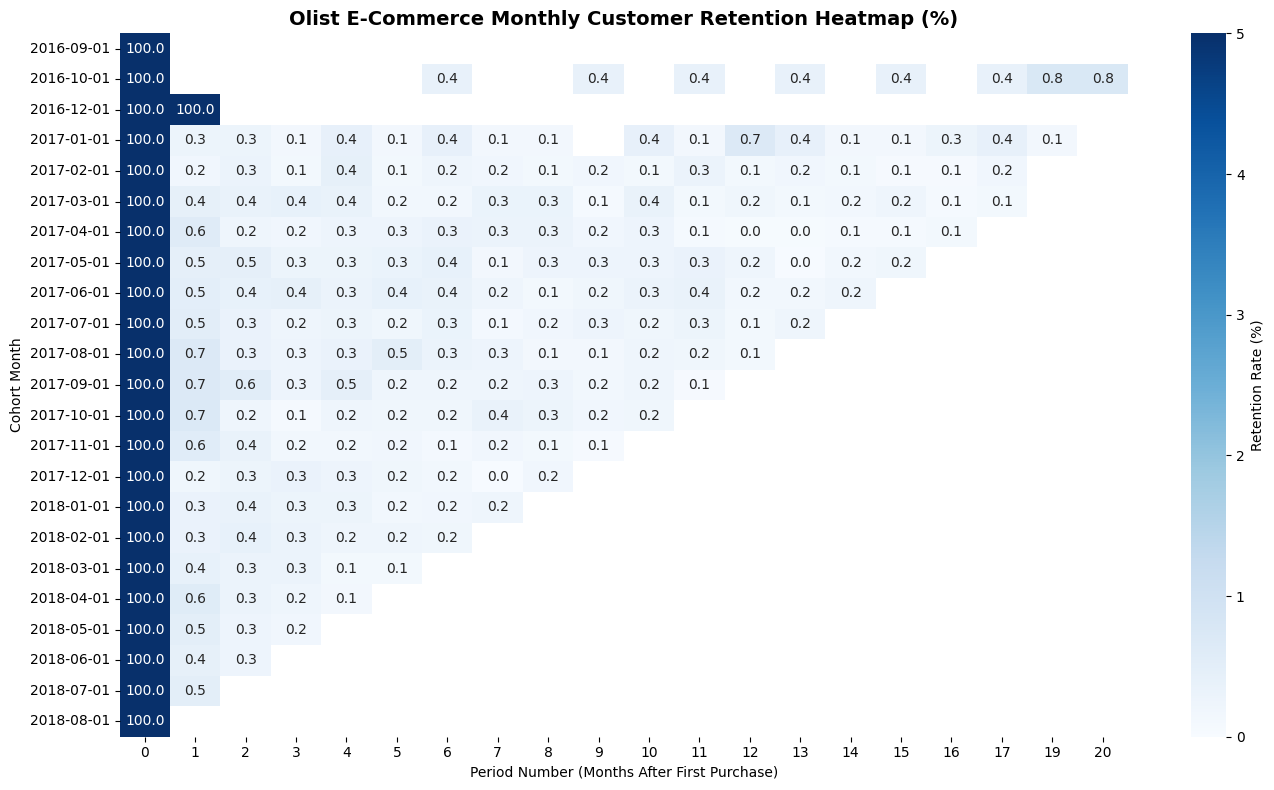

In [41]:
df_rates = pd.read_sql_query("SELECT * FROM q7_retention_rates;", conn)
retention_pivot = df_rates.pivot(index='cohort_month', columns='period_number', values='retention_rate_pct')

plt.figure(figsize=(14, 8))
sns.heatmap(retention_pivot, annot=True, fmt=".1f", cmap="Blues", vmin=0, vmax=5, cbar_kws={'label': 'Retention Rate (%)'})
plt.title('Olist E-Commerce Monthly Customer Retention Heatmap (%)', fontsize=14, fontweight='bold')
plt.xlabel('Period Number (Months After First Purchase)')
plt.ylabel('Cohort Month')
plt.tight_layout()
plt.show()

conn.close()